In [1]:
set.seed(405)
options(stringsAsFactors = FALSE)

In [2]:
required_packages <- c("rstan", "dplyr", "readr", "tibble", "bayesplot", "ggplot2")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_packages) > 0) install.packages(missing_packages, repos = "https://cloud.r-project.org")
invisible(lapply(required_packages, library, character.only = TRUE))
rstan_options(auto_write = TRUE)
options(mc.cores = parallel::detectCores())

Loading required package: StanHeaders


rstan version 2.32.7 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘bayesplot’ was built under R version 4.4.3”
This is bayesplot version 1.15.0

- Online documentation and

In [3]:
model_tbl <- readr::read_csv("../output/derived/gss_2024_model_table.csv", show_col_types = FALSE) %>%
  dplyr::mutate(
    degree = as.factor(degree),
    sex = as.factor(sex),
    region = as.factor(region),
    polviews_bin = factor(polviews_bin, levels = c("Liberal", "Moderate", "Conservative"))
  )

In [4]:
model_tbl_fit <- model_tbl %>%
  dplyr::filter(
    !is.na(confinan_ord), !is.na(polviews_bin), !is.na(age_std), !is.na(income_std),
    !is.na(degree), !is.na(sex), !is.na(region)
  )

x_formula <- stats::as.formula(~ age_std + income_std + degree + sex + region)
X <- stats::model.matrix(x_formula, data = model_tbl_fit)
X <- X[, colnames(X) != "(Intercept)", drop = FALSE]
y <- as.integer(model_tbl_fit$confinan_ord)
ideology_levels <- levels(model_tbl_fit$polviews_bin)
ideology_id <- as.integer(model_tbl_fit$polviews_bin)

if (!all(y %in% c(1L, 2L, 3L))) stop("Outcome contains values outside {1,2,3}.")
if (length(y) != nrow(X)) stop("Length mismatch: y and X rows differ after preprocessing.")
if (any(is.na(ideology_id))) stop("Ideology group contains missing values after preprocessing.")

stan_data <- list(
  N = nrow(X),
  K = ncol(X),
  G = length(ideology_levels),
  y = y,
  X = X,
  ideology_id = ideology_id
)

tibble::tibble(metric = c("N", "K", "G"), value = c(stan_data$N, stan_data$K, stan_data$G))

metric,value
<chr>,<int>
N,2223
K,10
G,3


In [5]:
stan_code <- "
data {
  int<lower=1> N;
  int<lower=1> K;
  int<lower=1> G;
  int<lower=1,upper=3> y[N];
  matrix[N, K] X;
  int<lower=1,upper=G> ideology_id[N];
}
parameters {
  vector[K] beta;
  ordered[2] c;
  real mu_alpha;
  real<lower=0> sigma_alpha;
  vector[G] z_alpha;
}
transformed parameters {
  vector[G] alpha;
  alpha = mu_alpha + sigma_alpha * z_alpha;
}
model {
  beta ~ normal(0, 1);
  c ~ normal(0, 2.5);
  mu_alpha ~ normal(0, 1);
  sigma_alpha ~ normal(0, 1);
  z_alpha ~ normal(0, 1);
  for (n in 1:N) {
    y[n] ~ ordered_logistic(alpha[ideology_id[n]] + X[n] * beta, c);
  }
}
generated quantities {
  vector[N] log_lik;
  int<lower=1,upper=3> y_rep[N];
  for (n in 1:N) {
    real eta_n;
    eta_n = alpha[ideology_id[n]] + X[n] * beta;
    log_lik[n] = ordered_logistic_lpmf(y[n] | eta_n, c);
    y_rep[n] = ordered_logistic_rng(eta_n, c);
  }
}
"
dir.create("../stan", recursive = TRUE, showWarnings = FALSE)
writeLines(stan_code, con = "../stan/model2_hierarchical_ordinal.stan")

In [6]:
if (exists("fit_m2_nuts")) rm(fit_m2_nuts)
gc()

sm_m2 <- rstan::stan_model(file = "../stan/model2_hierarchical_ordinal.stan", model_name = "model2_hierarchical_ordinal")
fit_m2_nuts <- rstan::sampling(
  object = sm_m2,
  data = stan_data,
  chains = 4,
  iter = 2000,
  warmup = 1000,
  seed = 405,
  refresh = 100,
  control = list(adapt_delta = 0.92)
 )

lp_draws <- rstan::extract(fit_m2_nuts, pars = "lp__", permuted = TRUE)$lp__
if (length(lp_draws) == 0) stop("Stan returned zero posterior draws. Restart kernel and rerun Cells 1-7.")
length(lp_draws)

,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,1549907,82.8,2431378,129.9,NA,2431378,129.9
Vcells,2788420,21.3,8388608,64.0,16384,5155541,39.4


[1] 4000

In [7]:
fit_summary_raw <- as.data.frame(rstan::summary(fit_m2_nuts)$summary, check.names = FALSE)
if (nrow(fit_summary_raw) == 0) stop("No Stan draws found for Model 2.")
fit_summary_raw$parameter <- rownames(fit_summary_raw)
fit_summary <- fit_summary_raw %>% dplyr::relocate(parameter)

summary_cols_preferred <- c("mean", "sd", "2.5%", "50%", "97.5%", "n_eff", "Rhat")
summary_cols_fallback <- c("Mean", "SD", "2.5%", "50%", "97.5%", "Bulk_ESS", "Rhat")
summary_cols_to_show <- if (all(summary_cols_preferred %in% colnames(fit_summary))) {
  summary_cols_preferred
} else {
  summary_cols_fallback[summary_cols_fallback %in% colnames(fit_summary)]
}

fit_summary %>%
  dplyr::select(dplyr::all_of(c("parameter", summary_cols_to_show))) %>%
  head(25)

,parameter,mean,sd,2.5%,50%,97.5%,n_eff,Rhat
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
beta[1],beta[1],-0.27415639,0.04298371,-0.35861681,-0.27458395,-0.18929519,4200.463,1.0000617
beta[2],beta[2],0.01886879,0.04472959,-0.06518576,0.01951196,0.10962222,3931.046,1.0009979
beta[3],beta[3],0.17391273,0.16459952,-0.15307641,0.17504720,0.48066003,1315.712,1.0003023
beta[4],beta[4],0.33420742,0.20332711,-0.06471482,0.33564521,0.71752781,1766.870,1.0014218
beta[5],beta[5],0.01240109,0.17692005,-0.33639750,0.01800402,0.34932469,1496.940,1.0007275
beta[6],beta[6],-0.20131359,0.18799078,-0.57333651,-0.19866169,0.16646834,1586.222,1.0007387
beta[7],beta[7],-0.22152483,0.08630093,-0.39097068,-0.22002283,-0.05528248,4821.819,0.9994290
beta[8],beta[8],0.22817462,0.13364780,-0.02785755,0.23114152,0.48410715,2506.620,1.0011978
beta[9],beta[9],0.06148848,0.12635637,-0.18756086,0.06420871,0.30095661,2465.295,1.0011452


In [8]:
ess_col <- if ("n_eff" %in% colnames(fit_summary)) "n_eff" else if ("Bulk_ESS" %in% colnames(fit_summary)) "Bulk_ESS" else NA_character_
rhat_col <- if ("Rhat" %in% colnames(fit_summary)) "Rhat" else NA_character_

sampler_params <- rstan::get_sampler_params(fit_m2_nuts, inc_warmup = FALSE)
n_divergences <- sum(vapply(sampler_params, function(x) sum(x[, "divergent__"]), numeric(1)))
max_treedepth <- max(vapply(sampler_params, function(x) max(x[, "treedepth__"]), numeric(1)))

diag_summary <- tibble::tibble(
  metric = c("max_rhat", "min_ess", "n_params_rhat_gt_1.01", "n_divergences", "max_treedepth"),
  value = c(
    if (!is.na(rhat_col)) max(fit_summary[[rhat_col]], na.rm = TRUE) else NA_real_,
    if (!is.na(ess_col)) min(fit_summary[[ess_col]], na.rm = TRUE) else NA_real_,
    if (!is.na(rhat_col)) sum(fit_summary[[rhat_col]] > 1.01, na.rm = TRUE) else NA_real_,
    n_divergences,
    max_treedepth
  )
)
diag_summary

metric,value
<chr>,<dbl>
max_rhat,1.003375
min_ess,996.454485
n_params_rhat_gt_1.01,0.000000
n_divergences,0.000000
max_treedepth,8.000000


In [9]:
alpha_draws <- rstan::extract(fit_m2_nuts, pars = "alpha", permuted = TRUE)$alpha
if (is.null(alpha_draws) || nrow(alpha_draws) == 0) stop("No alpha draws found.")
alpha_summary <- tibble::tibble(
  ideology = ideology_levels,
  mean = apply(alpha_draws, 2, mean),
  sd = apply(alpha_draws, 2, stats::sd),
  q025 = apply(alpha_draws, 2, stats::quantile, probs = 0.025),
  q50 = apply(alpha_draws, 2, stats::quantile, probs = 0.50),
  q975 = apply(alpha_draws, 2, stats::quantile, probs = 0.975)
)
alpha_summary

ideology,mean,sd,q025,q50,q975
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Liberal,0.14532556,0.8896712,-1.633070,0.16192908,1.855231
Moderate,0.00521340,0.8924929,-1.795717,0.02415464,1.692486
Conservative,0.09326077,0.8888222,-1.652704,0.11069632,1.819793


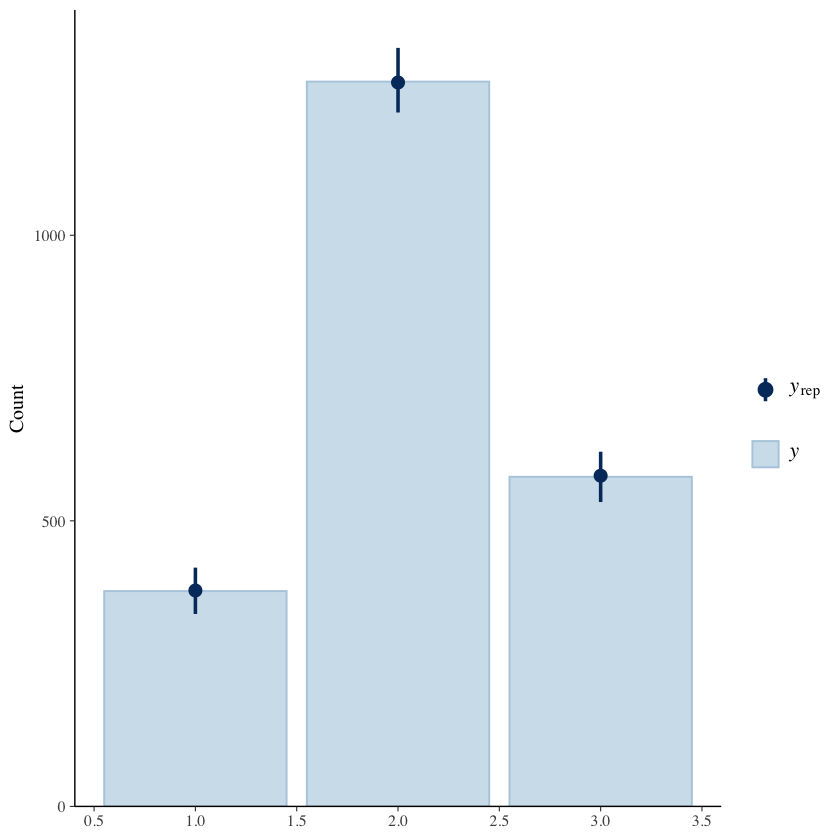

In [10]:
yrep_draws <- rstan::extract(fit_m2_nuts, pars = "y_rep", permuted = TRUE)$y_rep
if (is.null(yrep_draws) || nrow(yrep_draws) == 0) stop("No y_rep draws found.")
yrep_subset <- yrep_draws[sample.int(nrow(yrep_draws), size = min(200, nrow(yrep_draws))), , drop = FALSE]
ppc_plot <- bayesplot::ppc_bars(y = y, yrep = yrep_subset)
ppc_plot

In [11]:
dir.create("../output/model2_nuts", recursive = TRUE, showWarnings = FALSE)
saveRDS(fit_m2_nuts, file = "../output/model2_nuts/fit_m2_nuts.rds")
readr::write_csv(fit_summary, "../output/model2_nuts/fit_summary.csv")
readr::write_csv(diag_summary, "../output/model2_nuts/diagnostics_summary.csv")
readr::write_csv(alpha_summary, "../output/model2_nuts/alpha_summary.csv")
ggplot2::ggsave(filename = "../output/model2_nuts/ppc_bars_model2.png", plot = ppc_plot, width = 7, height = 4, dpi = 150)